# Pipeline final de screening y propuesta de nuevos materiales

## Modelos seleccionados

### `average_voltage`
El modelo seleccionado fue **XGBoost**:

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| Dummy | 1.416 | 1.760 | -0.000 |
| Ridge | 0.749 | 1.071 | 0.630 |
| Random Forest | 0.606 | 1.084 | 0.621 |
| **XGBoost** | **0.579** | **1.031** | **0.657** |

El modelo utiliza los mismos descriptores del notebook `02_feature engineering.ipynb`:  
**Magpie sobre `framework_formula` + variables dummy de `working_ion`.**

### `max_delta_volume`
Se utiliza **GINE_distance**, seleccionado en `06_modelado volume parte 2.ipynb`.

Resultados finales en test:

| Modelo | MAE | MedAE | RMSE | R² |
|---|---:|---:|---:|---:|
| XGB composición + log1p | 0.441 | **0.041** | 3.216 | -0.141 |
| **GINE_distance** | **0.404** | 0.056 | **2.918** | **0.060** |


## Flujo

1. Cargar los modelos ya entrenados.
2. Descargar materiales candidatos de `materials.summary`.
3. Excluir materiales que ya aparecen en `insertion_electrodes`.
4. Identificar el posible `working_ion` a partir de la composición.
5. Reconstruir el `framework_formula` eliminando el ion móvil.
6. Reproducir exactamente las features Magpie + dummies.
7. Predecir `average_voltage`.
8. Construir grafos estructurales y predecir `max_delta_volume`.
9. Aplicar filtros de estabilidad.
10. Obtener candidatos.


## Requisitos previos

Antes de ejecutar este notebook deben existir:

- `modelos_finales/xgboost_voltage.json`
- `modelos_finales/gine_distance_volume.pt`
- `datos_baterias_mp/X_train.csv`
- `datos_baterias_mp/baterias_clean.csv`

Los dos primeros archivos deben guardarse al final de los notebooks de modelado correspondientes.

In [1]:
import os
import json
import random
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from mp_api.client import MPRester

from pymatgen.core import Composition, Element

from matminer.featurizers.composition import ElementProperty

from xgboost import XGBRegressor

import torch
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

c:\venvs\battery_gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
CUDA disponible: False


### 1. Configuración general

In [ ]:
SEED = 42

DATA_DIR = Path("datos_baterias_mp")
MODEL_DIR = Path("modelos_finales")
OUTPUT_DIR = Path("resultados_screening")

OUTPUT_DIR.mkdir(exist_ok=True)

VOLTAGE_MODEL_PATH = (
    MODEL_DIR / "xgboost_voltage.json"
)

VOLUME_MODEL_PATH = (
    MODEL_DIR / "gine_distance_volume.pt"
)

X_TRAIN_PATH = (
    DATA_DIR / "X_train.csv"
)

CLEAN_DATA_PATH = (
    DATA_DIR / "baterias_clean.csv"
)

CANDIDATES_CACHE = (
    DATA_DIR / "screening_candidates.pkl"
)

RESULTS_PATH = (
    OUTPUT_DIR / "screening_predicciones.csv"
)

SHORTLIST_PATH = (
    OUTPUT_DIR / "candidatos_finales.csv"
)

API_KEY = os.environ.get(
    "MP_API_KEY"
)

if API_KEY is None:
    raise RuntimeError(
        "No se encontró la variable de entorno MP_API_KEY."
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


MAX_E_ABOVE_HULL = 0.05


MIN_NUM_ELEMENTS = 2
MAX_NUM_ELEMENTS = 5

MIN_NUM_SITES = 2
MAX_NUM_SITES = 100


TOP_N = 20


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

print("Device:", DEVICE)

Device: cpu


### 2. Comprobar archivos necesarios

In [3]:
required_files = [
    VOLTAGE_MODEL_PATH,
    VOLUME_MODEL_PATH,
    X_TRAIN_PATH,
    CLEAN_DATA_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    print("Faltan los siguientes archivos:")

    for path in missing_files:
        print(" -", path)

    raise FileNotFoundError(
        "Guarda primero los modelos finales desde "
        "04_modelado.ipynb y 06_modelado volume parte 2.ipynb."
    )

print("Todos los archivos necesarios están disponibles.")

Todos los archivos necesarios están disponibles.


# Cargar los modelos finales

### 3. Modelo de voltaje

El orden de las variables se recupera directamente de `X_train.csv`, por lo que el pipeline utiliza exactamente las columnas empleadas durante el entrenamiento original.

In [4]:
X_train_reference = pd.read_csv(
    X_TRAIN_PATH
)

VOLTAGE_FEATURE_COLUMNS = (
    X_train_reference.columns.tolist()
)

print(
    "Número de features esperadas:",
    len(VOLTAGE_FEATURE_COLUMNS)
)

voltage_model = XGBRegressor()

voltage_model.load_model(
    VOLTAGE_MODEL_PATH
)

print("XGBoost de voltaje cargado.")

Número de features esperadas: 142
XGBoost de voltaje cargado.


### 4. Arquitectura del modelo GINE

In [5]:
class GINEBattery(nn.Module):

    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_channels=64,
        dropout=0.10,
    ):
        super().__init__()

        self.node_encoder = nn.Linear(
            node_dim,
            hidden_channels,
        )

        def make_mlp():
            return nn.Sequential(
                nn.Linear(
                    hidden_channels,
                    hidden_channels,
                ),
                nn.ReLU(),
                nn.Linear(
                    hidden_channels,
                    hidden_channels,
                ),
            )

        self.conv1 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.conv2 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.conv3 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.head = nn.Sequential(
            nn.Linear(
                hidden_channels,
                64,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                64,
                1,
            ),
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
    ):
        x = self.node_encoder(
            x
        )

        x = torch.relu(
            self.conv1(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv2(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv3(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = global_mean_pool(
            x,
            batch,
        )

        return self.head(
            x
        ).squeeze(-1)

### 5. Cargar checkpoint de `GINE_distance`

In [6]:
checkpoint = torch.load(
    VOLUME_MODEL_PATH,
    map_location=DEVICE,
)

required_checkpoint_keys = {
    "model_state_dict",
    "node_mean",
    "node_std",
    "cutoff",
    "node_dim",
    "edge_dim",
}

missing_checkpoint_keys = (
    required_checkpoint_keys
    - set(checkpoint.keys())
)

if missing_checkpoint_keys:
    raise KeyError(
        "El checkpoint de GINE no contiene: "
        f"{sorted(missing_checkpoint_keys)}"
    )

GNN_CUTOFF = float(
    checkpoint["cutoff"]
)

GNN_NODE_MODE = checkpoint.get(
    "node_mode",
    "atomic4",
)

GNN_EDGE_MODE = checkpoint.get(
    "edge_mode",
    "distance",
)

GNN_TARGET_TRANSFORM = checkpoint.get(
    "target_transform",
    "none",
)

volume_model = GINEBattery(
    node_dim=int(
        checkpoint["node_dim"]
    ),
    edge_dim=int(
        checkpoint["edge_dim"]
    ),
    hidden_channels=int(
        checkpoint.get(
            "hidden_channels",
            64,
        )
    ),
    dropout=float(
        checkpoint.get(
            "dropout",
            0.10,
        )
    ),
).to(
    DEVICE
)

volume_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

volume_model.eval()

node_mean = checkpoint[
    "node_mean"
].float()

node_std = checkpoint[
    "node_std"
].float()

print("GINE cargado correctamente.")
print("Cutoff:", GNN_CUTOFF)
print("Node mode:", GNN_NODE_MODE)
print("Edge mode:", GNN_EDGE_MODE)

GINE cargado correctamente.
Cutoff: 4.0
Node mode: atomic4
Edge mode: distance


# Definir la química conocida

### 6. Iones de trabajo presentes en el dataset original

No se inventan nuevos tipos de ion. El screening se restringe a los `working_ion` ya representados en los datos de entrenamiento.

In [7]:
known_batteries = pd.read_csv(
    CLEAN_DATA_PATH
)

WORKING_IONS = sorted(
    known_batteries[
        "working_ion"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(
    "Working ions presentes en el dataset:"
)

print(
    WORKING_IONS
)

Working ions presentes en el dataset:
['Al', 'Ca', 'Cs', 'K', 'Li', 'Mg', 'Na', 'Rb', 'Y', 'Zn']


In [8]:
ion_counts = (
    known_batteries[
        "working_ion"
    ]
    .value_counts()
)


# Se conservan únicamente los iones con al menos 400 observaciones en el dataset original.
MIN_ION_SAMPLES = 400

SCREENING_IONS = (
    ion_counts[
        ion_counts >= MIN_ION_SAMPLES
    ]
    .index
    .tolist()
)

print(
    "Iones utilizados en el screening final:",
    SCREENING_IONS
)

Iones utilizados en el screening final: ['Li', 'Mg', 'Ca', 'Zn', 'Na']


In [24]:
y_voltage_reference = (
    known_batteries["average_voltage"]
    .dropna()
    .astype(float)
)

print(
    "Voltajes de referencia disponibles:",
    len(y_voltage_reference),
)

Voltajes de referencia disponibles: 6847


### 7. Funciones para identificar el ion y reconstruir el framework

En el dataset original, los descriptores Magpie se calcularon sobre `framework_formula`, mientras que `working_ion` se añadió como variable dummy.

Para reproducir esta lógica en un material candidato:

- se detecta si contiene uno de los iones conocidos;
- ese elemento se toma como posible `working_ion`;
- se elimina dicho elemento de la composición;
- la composición restante constituye el `framework`.

Ejemplo:

`LiFePO4` → `working_ion = Li` → `framework = FePO4`.

In [9]:
def composition_elements(
    composition,
):
    if not isinstance(
        composition,
        Composition,
    ):
        composition = Composition(
            composition
        )

    return {
        str(element)
        for element
        in composition.elements
    }


def find_working_ions(
    composition,
    working_ions=SCREENING_IONS,
):
    present_elements = (
        composition_elements(
            composition
        )
    )

    return [
        ion
        for ion in working_ions
        if ion in present_elements
    ]


def remove_working_ion(
    composition,
    working_ion,
):
    if not isinstance(
        composition,
        Composition,
    ):
        composition = Composition(
            composition
        )

    amounts = {
        str(element): amount
        for element, amount
        in composition.items()
        if str(element) != working_ion
    }

    if len(amounts) == 0:
        return None

    return Composition(
        amounts
    )

# Obtener nuevos candidatos de Materials Project

### 8. Recuperar IDs de electrodos ya conocidos

Estos materiales se utilizan únicamente para excluir del screening materiales que ya forman parte del conjunto de electrodos de inserción conocido.

In [10]:
with MPRester(API_KEY) as mpr:

    electrode_docs = (
        mpr.materials
        .insertion_electrodes
        .search(
            fields=[
                "material_ids",
            ],
            chunk_size=1000,
        )
    )


known_electrode_ids = set()

for doc in electrode_docs:

    ids = getattr(
        doc,
        "material_ids",
        None,
    )

    if ids is None:
        continue

    for material_id in ids:
        known_electrode_ids.add(
            str(material_id)
        )


print(
    "Material IDs asociados a electrodos conocidos:",
    len(known_electrode_ids)
)

mp_api.client.core.client - WARNING - Dataset for insertion-electrodes already exists at C:\Users\NereaBorjaGonzález\mp_datasets\build\collections\insertion-electrodes, returning existing dataset.
mp_api.client.core.client - INFO - Delete or move existing dataset or re-run search query with MPRester(force_renew=True) to refresh local dataset.
C:\Users\NereaBorjaGonzález\AppData\Local\Temp\ipykernel_20332\2911091194.py:17: MPDatasetIterationWarning: 
                Iterating through arrow-based MPDatasets is sub-optimal, consider using
                idiomatic arrow patterns. See MP's docs on MPDatasets for relevant examples:
                docs.materialsproject.org/materials-project-data-lakehouse/arrow-datasets
                
  for doc in electrode_docs:


Material IDs asociados a electrodos conocidos: 17380


### 9. Descargar materiales del catálogo general

Se utiliza `materials.summary`, no `insertion_electrodes`, porque ahora buscamos materiales que **no hayan sido utilizados como ejemplos etiquetados de electrodos**.

El filtro `energy_above_hull <= 0.05 eV/átomo` se utiliza para reducir el espacio de búsqueda.

In [11]:
if CANDIDATES_CACHE.exists():

    candidates_raw = pd.read_pickle(
        CANDIDATES_CACHE
    )

    print(
        "Candidatos cargados desde caché:",
        len(candidates_raw)
    )

else:

    with MPRester(API_KEY) as mpr:

        candidate_docs = (
            mpr.materials
            .summary
            .search(
                energy_above_hull=(
                    0.0,
                    MAX_E_ABOVE_HULL,
                ),
                num_elements=(
                    MIN_NUM_ELEMENTS,
                    MAX_NUM_ELEMENTS,
                ),
                num_sites=(
                    MIN_NUM_SITES,
                    MAX_NUM_SITES,
                ),
                fields=[
                    "material_id",
                    "formula_pretty",
                    "composition",
                    "structure",
                    "energy_above_hull",
                    "formation_energy_per_atom",
                    "is_stable",
                    "density",
                    "volume",
                    "nsites",
                    "elements",
                    "band_gap",
                    "is_metal",
                    "theoretical",
                ],
                chunk_size=1000,
            )
        )

    rows = []

    for doc in candidate_docs:

        rows.append(
            {
                "material_id": str(
                    doc.material_id
                ),
                "formula_pretty": (
                    doc.formula_pretty
                ),
                "composition": (
                    doc.composition
                ),
                "structure": (
                    doc.structure
                ),
                "energy_above_hull": (
                    doc.energy_above_hull
                ),
                "formation_energy_per_atom": (
                    doc.formation_energy_per_atom
                ),
                "is_stable": (
                    doc.is_stable
                ),
                "density": (
                    doc.density
                ),
                "volume": (
                    doc.volume
                ),
                "nsites": (
                    doc.nsites
                ),
                "band_gap": (
                    doc.band_gap
                ),
                "is_metal": (
                    doc.is_metal
                ),
                "theoretical": (
                    doc.theoretical
                ),
            }
        )

    candidates_raw = pd.DataFrame(
        rows
    )

    candidates_raw.to_pickle(
        CANDIDATES_CACHE
    )

    print(
        "Candidatos descargados:",
        len(candidates_raw)
    )

Retrieving SummaryDoc documents: 100%|██████████| 70558/70558 [04:19<00:00, 271.73it/s]


Candidatos descargados: 70558


### 10. Excluir electrodos ya conocidos

In [12]:
candidates = (
    candidates_raw[
        ~candidates_raw[
            "material_id"
        ].isin(
            known_electrode_ids
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Candidatos tras excluir electrodos conocidos:",
    len(candidates)
)

Candidatos tras excluir electrodos conocidos: 64143


### 11. Identificar candidatos compatibles con los iones conocidos

Para evitar asignar arbitrariamente un ion a una estructura, solo se mantienen composiciones que contengan al menos uno de los `working_ion` observados en el dataset original.

Si una composición contiene más de uno, se genera una fila por cada posible ion y se marca como caso ambiguo.

In [13]:
expanded_rows = []

for _, row in candidates.iterrows():

    composition = row[
        "composition"
    ]

    possible_ions = (
        find_working_ions(
            composition
        )
    )

    if len(possible_ions) == 0:
        continue

    for ion in possible_ions:

        framework_composition = (
            remove_working_ion(
                composition,
                ion,
            )
        )

        if framework_composition is None:
            continue

        new_row = row.to_dict()

        new_row[
            "working_ion"
        ] = ion

        new_row[
            "framework_composition"
        ] = framework_composition

        new_row[
            "framework_formula"
        ] = (
            framework_composition
            .reduced_formula
        )

        new_row[
            "n_possible_working_ions"
        ] = len(
            possible_ions
        )

        expanded_rows.append(
            new_row
        )


screening_df = pd.DataFrame(
    expanded_rows
)

print(
    "Combinaciones material/ion para screening:",
    len(screening_df)
)

display(
    screening_df[
        [
            "material_id",
            "formula_pretty",
            "working_ion",
            "framework_formula",
            "energy_above_hull",
            "n_possible_working_ions",
        ]
    ].head(10)
)

Combinaciones material/ion para screening: 18561


,material_id,formula_pretty,working_ion,framework_formula,energy_above_hull,n_possible_working_ions
0,mp-985286,Ac2Mg,Mg,Ac,0.032931,1
1,mp-1183085,Ac2Mg,Mg,Ac,0.033050,1
2,mp-1183089,Ac2Mg,Mg,Ac,0.020178,1
3,mp-1183074,Ac2MgGa,Mg,Ac2Ga,0.000000,1
4,mp-1183078,Ac2MgPb,Mg,Ac2Pb,0.000000,1
5,mp-866103,Ac2MgSn,Mg,Ac2Sn,0.000000,1
6,mp-1183079,Ac2MgTl,Mg,Ac2Tl,0.000000,1
7,mp-1183066,Ac2ZnAu,Zn,Ac2Au,0.008908,1
8,mp-865535,Ac2ZnGa,Zn,Ac2Ga,0.004479,1
9,mp-866018,Ac2ZnGe,Zn,Ac2Ge,0.000000,1


# Predicción de voltaje

### 12. Reproducir Magpie + dummies

Esta sección reproduce el procedimiento de `02_feature engineering.ipynb`.

In [14]:
magpie = ElementProperty.from_preset(
    "magpie"
)


def build_voltage_features(
    dataframe,
):
    temp = dataframe.copy()


    # Magpie sobre framework
   

    magpie_values = []

    labels = (
        magpie.feature_labels()
    )

    for composition in temp[
        "framework_composition"
    ]:

        values = magpie.featurize(
            composition
        )

        magpie_values.append(
            values
        )

    magpie_df = pd.DataFrame(
        magpie_values,
        columns=labels,
        index=temp.index,
    )
    
    # Dummies working_ion

    ion_dummies = pd.get_dummies(
        temp["working_ion"],
        prefix="working_ion",
        dtype=int,
    )

    features = pd.concat(
        [
            magpie_df,
            ion_dummies,
        ],
        axis=1,
    )

    for column in VOLTAGE_FEATURE_COLUMNS:

        if column not in features.columns:
            features[
                column
            ] = 0

    extra_columns = [
        column
        for column in features.columns
        if column not in VOLTAGE_FEATURE_COLUMNS
    ]

    if extra_columns:
        print(
            "Columnas nuevas no utilizadas por el modelo:",
            extra_columns,
        )

    features = features[
        VOLTAGE_FEATURE_COLUMNS
    ].copy()

    if features.isna().any().any():

        n_nan = int(
            features
            .isna()
            .sum()
            .sum()
        )

        raise ValueError(
            f"Se han generado {n_nan} valores NaN "
            "en las features de voltaje."
        )

    return features

In [15]:
X_candidates_voltage = (
    build_voltage_features(
        screening_df
    )
)

print(
    "Shape de features para voltaje:",
    X_candidates_voltage.shape
)

print(
    "Coincidencia exacta de columnas:",
    X_candidates_voltage.columns.tolist()
    == VOLTAGE_FEATURE_COLUMNS
)

Shape de features para voltaje: (18561, 142)
Coincidencia exacta de columnas: True


### 13. Predecir `average_voltage`

In [16]:
screening_df[
    "pred_average_voltage"
] = voltage_model.predict(
    X_candidates_voltage
)

display(
    screening_df[
        [
            "material_id",
            "formula_pretty",
            "working_ion",
            "framework_formula",
            "pred_average_voltage",
        ]
    ]
    .sort_values(
        "pred_average_voltage",
        ascending=False,
    )
    .head(10)
)

,material_id,formula_pretty,working_ion,framework_formula,pred_average_voltage
2243,mp-16795,CaAlF5,Ca,AlF5,6.504566
12420,mp-3855,Na2BeF4,Na,BeF4,6.276880
12419,mp-3318,Na2BeF4,Na,BeF4,6.276880
7087,mp-755739,Li3VP2HO8,Li,VP2HO8,6.165988
6510,mp-780736,Li2VP2HO8,Li,VP2HO8,6.165988
2843,mp-1389691,CaNiF5,Ca,NiF5,5.932508
2842,mp-1376405,CaNiF5,Ca,NiF5,5.932508
14061,mp-4752,Na5Al3F14,Na,Al3F14,5.921801
2455,mp-1404740,CaFeF6,Ca,FeF6,5.737030
5411,mp-4622,Li2BeF4,Li,BeF4,5.696194


# Predicción de `max_delta_volume`

### 14. Construcción de grafos

Se reproduce la representación seleccionada para `GINE_distance`:

- nodos: `[Z, masa atómica, electronegatividad, radio atómico]`;
- aristas: vecinos periódicos dentro del cutoff;
- `edge_attr`: distancia interatómica.

Los vecinos periódicos con el mismo índice de sitio (`i == j`) no se eliminan, porque pueden representar imágenes periódicas válidas.

In [17]:
def atom_features(
    site,
    mode="atomic4",
):
    element = Element(
        site.specie.symbol
    )

    if mode == "atomic4":

        return [
            float(
                element.Z
            ),
            float(
                element.atomic_mass
            ),
            float(
                element.X
            )
            if element.X is not None
            else 0.0,
            float(
                element.atomic_radius
            )
            if element.atomic_radius
            is not None
            else 0.0,
        ]

    raise ValueError(
        f"node feature mode desconocido: {mode}"
    )


def get_node_features(
    structure,
    mode="atomic4",
):
    return torch.tensor(
        [
            atom_features(
                site,
                mode=mode,
            )
            for site in structure
        ],
        dtype=torch.float32,
    )


def structure_to_graph_prediction(
    structure,
    cutoff=GNN_CUTOFF,
    node_mode=GNN_NODE_MODE,
):
    x = get_node_features(
        structure,
        mode=node_mode,
    )

    edges = []
    distances = []

    for i in range(
        len(structure)
    ):

        neighbors = (
            structure.get_neighbors(
                structure[i],
                cutoff,
            )
        )

        for neighbor in neighbors:

            j = int(
                neighbor.index
            )

            distance = float(
                neighbor.nn_distance
            )

            edges.append(
                [i, j]
            )

            distances.append(
                distance
            )

    if len(edges) == 0:

        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long,
        )

        edge_attr = torch.empty(
            (0, 1),
            dtype=torch.float32,
        )

    else:

        edge_index = torch.tensor(
            edges,
            dtype=torch.long,
        ).t().contiguous()

        edge_attr = torch.tensor(
            distances,
            dtype=torch.float32,
        ).view(
            -1,
            1,
        )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
    )

### 15. Función de inferencia GINE

In [18]:
def predict_volume_single(
    structure,
):
    graph = (
        structure_to_graph_prediction(
            structure
        )
    )

    # Normalización aprendida en train
    graph.x = (
        graph.x - node_mean
    ) / node_std

    graph = graph.to(
        DEVICE
    )

    batch = torch.zeros(
        graph.num_nodes,
        dtype=torch.long,
        device=DEVICE,
    )

    with torch.no_grad():

        prediction = volume_model(
            graph.x,
            graph.edge_index,
            graph.edge_attr,
            batch,
        )

    prediction = float(
        prediction
        .detach()
        .cpu()
        .item()
    )

    if GNN_TARGET_TRANSFORM == "log1p":
        prediction = float(
            np.expm1(
                prediction
            )
        )

    return prediction

### 16. Predecir volumen

Una misma estructura puede aparecer más de una vez si contiene varios posibles `working_ion`. Como la GNN seleccionada no utiliza explícitamente la etiqueta `working_ion`, la predicción estructural se calcula una sola vez por `material_id` y después se incorpora a todas sus filas.

In [19]:
unique_structures = (
    screening_df[
        [
            "material_id",
            "structure",
        ]
    ]
    .drop_duplicates(
        subset="material_id"
    )
)

volume_predictions = {}

for i, row in unique_structures.iterrows():

    try:

        prediction = (
            predict_volume_single(
                row["structure"]
            )
        )

        volume_predictions[
            row["material_id"]
        ] = prediction

    except Exception as exc:

        print(
            "Error en",
            row["material_id"],
            ":",
            exc,
        )

        volume_predictions[
            row["material_id"]
        ] = np.nan


screening_df[
    "pred_max_delta_volume"
] = screening_df[
    "material_id"
].map(
    volume_predictions
)

print(
    "Predicciones GNN disponibles:",
    screening_df[
        "pred_max_delta_volume"
    ]
    .notna()
    .sum()
)

Predicciones GNN disponibles: 18561


# Control de calidad y screening

### 17. Eliminar predicciones no válidas

Si el modelo produce valores negativos, se marcan para inspección porque `max_delta_volume` no debería interpretarse físicamente como negativo.

In [20]:
screening_df[
    "volume_prediction_valid"
] = (
    screening_df[
        "pred_max_delta_volume"
    ].notna()
    &
    (
        screening_df[
            "pred_max_delta_volume"
        ] >= 0
    )
)

print(
    screening_df[
        "volume_prediction_valid"
    ].value_counts(
        dropna=False
    )
)

volume_prediction_valid
True    18561
Name: count, dtype: int64


### 18. Filtrado

Se mantienen candidatos:

- con predicciones válidas;
- dentro del filtro termodinámico ya aplicado;
- con voltaje predicho positivo entre el percentil 5 y 95.

No se fija inicialmente un umbral rígido de `max_delta_volume`: se utilizará un enfoque multiobjetivo para evitar escoger arbitrariamente un único valor de corte.

In [25]:
VOLTAGE_P99 = (
    y_voltage_reference
    .quantile(0.99)
)

print(
    "Percentil 99% del voltaje:",
    VOLTAGE_P99
)

screened = (

    screening_df[

        screening_df[
            "volume_prediction_valid"
        ]

        &

        screening_df[
            "pred_average_voltage"
        ].notna()

        &

        screening_df[
            "pred_average_voltage"
        ].between(
            0,
            VOLTAGE_P99,
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)

print(
    "Candidatos tras control de calidad:",
    len(screened)
)

Percentil 99% del voltaje: 5.745745490348271
Candidatos tras control de calidad: 16231


# Ranking multiobjetivo

### 19. Frente de Pareto

In [26]:
def pareto_mask(
    voltage,
    volume,
):
    voltage = np.asarray(
        voltage,
        dtype=float,
    )

    volume = np.asarray(
        volume,
        dtype=float,
    )

    n = len(voltage)

    efficient = np.ones(
        n,
        dtype=bool,
    )

    for i in range(n):

        dominated_by_other = (
            (voltage >= voltage[i])
            &
            (volume <= volume[i])
            &
            (
                (voltage > voltage[i])
                |
                (volume < volume[i])
            )
        )

        dominated_by_other[i] = False

        if dominated_by_other.any():
            efficient[i] = False

    return efficient



screened["pareto"] = pareto_mask(
    screened[
        "pred_average_voltage"
    ].to_numpy(),
    screened[
        "pred_max_delta_volume"
    ].to_numpy(),
)



pareto_df = (
    screened[
        screened["pareto"]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "Candidatos antes de Pareto:",
    len(screened)
)

print(
    "Candidatos en el frente de Pareto:",
    len(pareto_df)
)

display(
    pareto_df[
        [
            "material_id",
            "formula_pretty",
            "working_ion",
            "energy_above_hull",
            "is_stable",
            "pred_average_voltage",
            "pred_max_delta_volume",
        ]
    ]
)

Candidatos antes de Pareto: 16231
Candidatos en el frente de Pareto: 1


,material_id,formula_pretty,working_ion,energy_above_hull,is_stable,pred_average_voltage,pred_max_delta_volume
0,mp-1404740,CaFeF6,Ca,0.02127,False,5.73703,0.085989


### 20. Distribución de valores predichos de max_delta_volume en el dataset

In [27]:
volume_counts_df = (
    screening_df[
        "pred_max_delta_volume"
    ]
    .value_counts()
    .reset_index()
)

volume_counts_df.columns = [
    "pred_max_delta_volume",
    "n_candidates",
]

volume_counts_df[
    "percentage"
] = (
    volume_counts_df[
        "n_candidates"
    ]
    / len(screening_df)
    * 100
)

display(
    volume_counts_df.head(20)
)

,pred_max_delta_volume,n_candidates,percentage
0,0.085989,12273,66.122515
1,5.586908,3,0.016163
2,5.539691,3,0.016163
3,3.996453,3,0.016163
4,5.054260,3,0.016163
5,1.582740,3,0.016163
6,4.997857,3,0.016163
7,4.679815,3,0.016163
8,5.222527,3,0.016163
9,3.999484,3,0.016163


### 21. Lista de candidatos final sin usar Pareto como filtro

In [28]:
# El 66% de los candidatos tienen el mismo valor de max_delta_volume predicho, por lo que no es un buen criterio de filtrado.


shortlist = (
    screened

    .sort_values(
        [
            "is_stable",
            "energy_above_hull",
            "pred_average_voltage",
        ],
        ascending=[
            False,
            True,
            False,
        ],
    )

    .drop_duplicates(
        subset=[
            "formula_pretty",
            "working_ion",
        ],
        keep="first",
    )

    .head(TOP_N)

    .reset_index(drop=True)
)

display(
    shortlist[
        [
            "material_id",
            "formula_pretty",
            "working_ion",
            "framework_formula",
            "energy_above_hull",
            "is_stable",
            "pred_average_voltage",
            "pred_max_delta_volume",
            "pareto",
        ]
    ]
)

,material_id,formula_pretty,working_ion,framework_formula,energy_above_hull,is_stable,pred_average_voltage,pred_max_delta_volume,pareto
0,mp-4622,Li2BeF4,Li,BeF4,0.0,True,5.696194,0.085989,False
1,mp-35759,Li2NiF4,Li,NiF4,0.0,True,5.685735,0.085989,False
2,mp-1932798,CaCr2F12,Ca,CrF6,0.0,True,5.539319,0.085989,False
3,mp-5926,KCaF3,Ca,KF3,0.0,True,5.391247,0.085989,False
4,mp-1354389,Ba2CaCo2CuF14,Ca,Ba2Co2CuF14,0.0,True,5.354031,0.085989,False
5,mp-15254,Li3AlF6,Li,AlF6,0.0,True,5.279366,0.085989,False
6,mp-776627,Li3FeF6,Li,FeF6,0.0,True,5.279250,0.085989,False
7,mp-1211093,LiCaFeF6,Ca,LiFeF6,0.0,True,5.278087,0.085989,False
8,mp-37458,Na2HF4,Na,HF4,0.0,True,5.212194,0.085989,False
9,mp-559584,LiCaNiF6,Ca,LiNiF6,0.0,True,5.211538,0.085989,False


### 22. Porcentaje de materiales con el mismo volumen

In [30]:
most_common_volume = (
    screened["pred_max_delta_volume"]
    .mode()
    .iloc[0]
)

same_value_mask = np.isclose(
    screened["pred_max_delta_volume"].to_numpy(dtype=float),
    float(most_common_volume),
    rtol=1e-7,
    atol=1e-9,
)

print(
    "Valor de volumen predicho más frecuente:",
    most_common_volume,
)

volume_diagnostic = pd.DataFrame(
    {
        "n_screened": [
            len(screened)
        ],
        "n_same_baseline_volume": [
            same_value_mask.sum()
        ],
        "n_unique_material_ids_same_volume": [
            screened.loc[
                same_value_mask,
                "material_id"
            ].nunique()
        ],
        "percentage_same_volume": [
            same_value_mask.mean() * 100
        ],
    }
)

display(volume_diagnostic)

Valor de volumen predicho más frecuente: 0.08598875254392624


,n_screened,n_same_baseline_volume,n_unique_material_ids_same_volume,percentage_same_volume
0,16231,12015,11253,74.025014


### 20. Visualización del espacio de screening

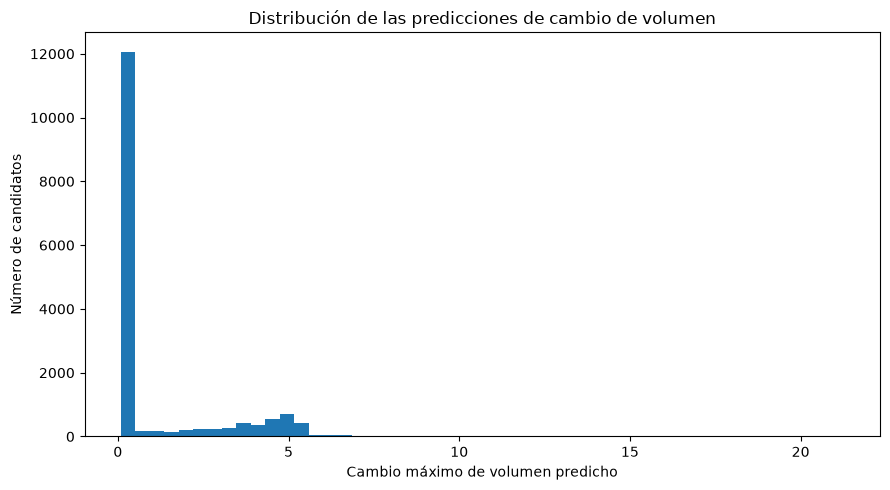

In [31]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    screened[
        "pred_max_delta_volume"
    ],
    bins=50,
)

plt.xlabel(
    "Cambio máximo de volumen predicho"
)

plt.ylabel(
    "Número de candidatos"
)

plt.title(
    "Distribución de las predicciones de cambio de volumen"
)

plt.tight_layout()

plt.show()

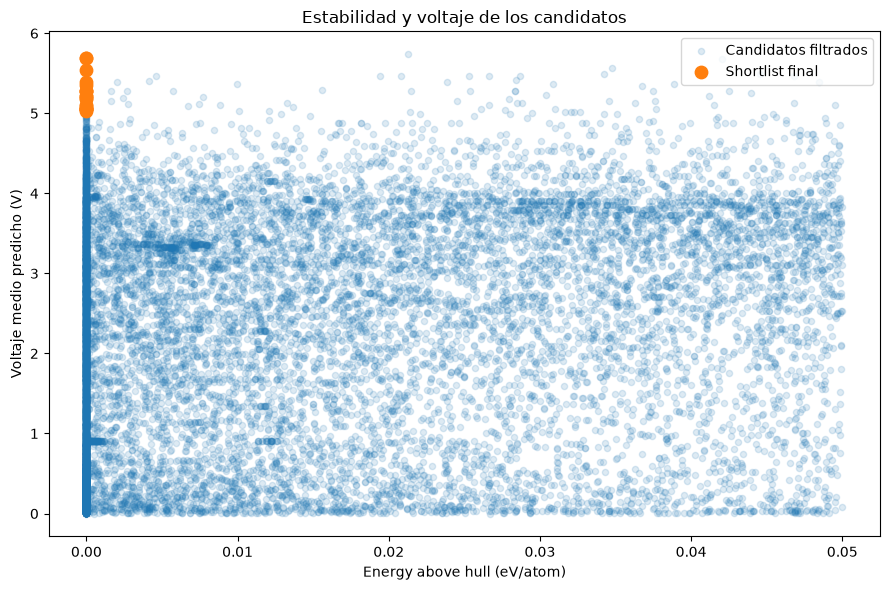

In [32]:
plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    screened[
        "energy_above_hull"
    ],
    screened[
        "pred_average_voltage"
    ],
    alpha=0.15,
    s=20,
    label="Candidatos filtrados",
)

plt.scatter(
    shortlist[
        "energy_above_hull"
    ],
    shortlist[
        "pred_average_voltage"
    ],
    s=80,
    label="Shortlist final",
)

plt.xlabel(
    "Energy above hull (eV/atom)"
)

plt.ylabel(
    "Voltaje medio predicho (V)"
)

plt.title(
    "Estabilidad y voltaje de los candidatos"
)

plt.legend()

plt.tight_layout()

plt.show()

### 23. Comparar candidatos con el dominio del entrenamiento

Como control sencillo de extrapolación, se comparan los voltajes predichos con el rango de voltajes observado en el dataset original.

Text(0, 0.5, '')

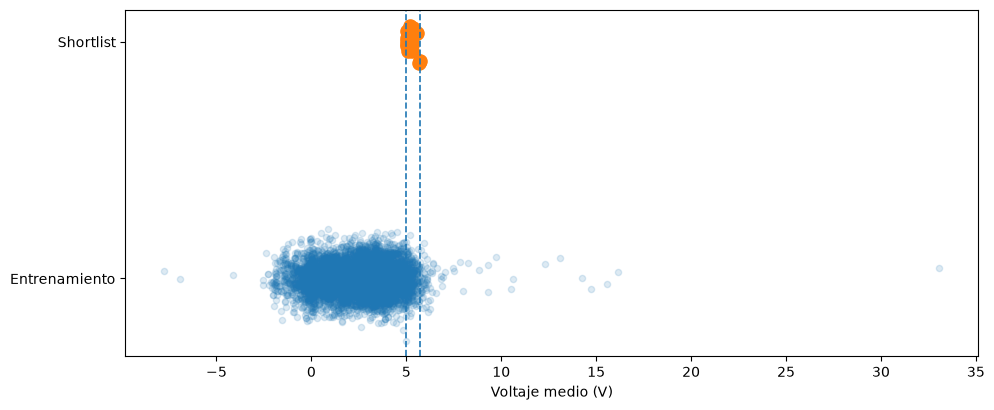

In [35]:
rng = np.random.default_rng(42)

y_train_jitter = rng.normal(
    loc=0,
    scale=0.06,
    size=len(y_voltage_reference),
)

y_shortlist_jitter = rng.normal(
    loc=1,
    scale=0.03,
    size=len(shortlist),
)

plt.figure(
    figsize=(11, 4.5)
)


plt.scatter(
    y_voltage_reference,
    y_train_jitter,
    alpha=0.15,
    s=20,
    label="Entrenamiento",
)


plt.scatter(
    shortlist[
        "pred_average_voltage"
    ],
    y_shortlist_jitter,
    s=90,
    label="Shortlist final",
)


p95 = y_voltage_reference.quantile(0.95)
p99 = y_voltage_reference.quantile(0.99)

plt.axvline(
    p95,
    linestyle="--",
    linewidth=1.2,
    label=f"P95 train = {p95:.2f} V",
)

plt.axvline(
    p99,
    linestyle="--",
    linewidth=1.2,
    label=f"P99 train = {p99:.2f} V",
)

plt.yticks(
    [0, 1],
    [
        "Entrenamiento",
        "Shortlist",
    ],
)

plt.xlabel(
    "Voltaje medio (V)"
)

plt.ylabel("")


Train: (5477, 142)
Shortlist: (20, 142)


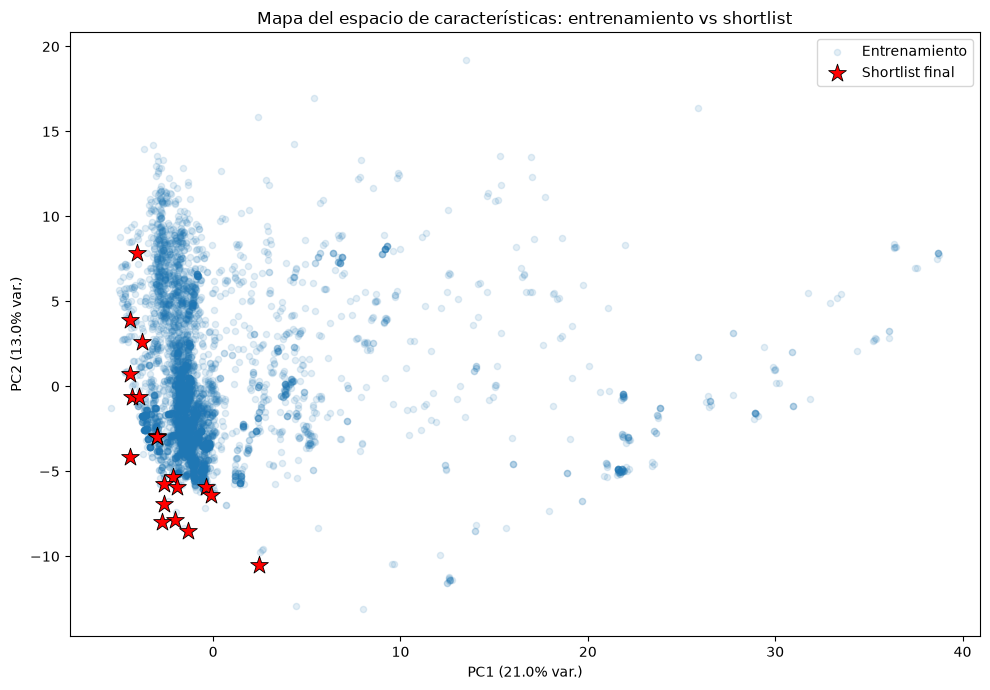

In [36]:
X_train_pca = (
    X_train_reference
    .copy()
)


X_shortlist_pca = (
    build_voltage_features(
        shortlist
    )
)

print(
    "Train:",
    X_train_pca.shape
)

print(
    "Shortlist:",
    X_shortlist_pca.shape
)

assert (
    X_train_pca.columns.tolist()
    ==
    X_shortlist_pca.columns.tolist()
)


scaler_pca = StandardScaler()

X_train_scaled = (
    scaler_pca.fit_transform(
        X_train_pca
    )
)

X_shortlist_scaled = (
    scaler_pca.transform(
        X_shortlist_pca
    )
)


pca = PCA(
    n_components=2
)

train_2d = (
    pca.fit_transform(
        X_train_scaled
    )
)

shortlist_2d = (
    pca.transform(
        X_shortlist_scaled
    )
)



plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    train_2d[:, 0],
    train_2d[:, 1],
    alpha=0.12,
    s=20,
    label="Entrenamiento",
)

plt.scatter(
    shortlist_2d[:, 0],
    shortlist_2d[:, 1],
    s=180,
    marker="*",
    color="red",
    edgecolors="black",
    linewidths=0.6,
    label="Shortlist final",
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)"
)

plt.title(
    "Mapa del espacio de características: entrenamiento vs shortlist"
)

plt.legend()

plt.tight_layout()

plt.show()

El porcentaje indicado en cada eje representa la proporción de variabilidad total de las características originales explicada por cada componente principal. La suma de ambos porcentajes indica la fracción de información representada en la proyección bidimensional.



### 24. Exportar todas las predicciones y la lista corta

El CSV no puede guardar los objetos `Structure` y `Composition`, por lo que se eliminan únicamente al exportar. El DataFrame en memoria conserva ambos.

In [37]:
export_columns = [
    column
    for column in screened.columns
    if column not in {
        "structure",
        "composition",
        "framework_composition",
    }
]

screened[
    export_columns
].to_csv(
    RESULTS_PATH,
    index=False,
)


shortlist_export_columns = [
    "material_id",
    "formula_pretty",
    "working_ion",
    "framework_formula",
    "energy_above_hull",
    "is_stable",
    "pred_average_voltage",
    "pred_max_delta_volume",
]

shortlist[
    shortlist_export_columns
].to_csv(
    SHORTLIST_PATH,
    index=False,
)


print(
    "Predicciones completas:",
    RESULTS_PATH
)

print(
    "Lista corta:",
    SHORTLIST_PATH
)


Predicciones completas: resultados_screening\screening_predicciones.csv
Lista corta: resultados_screening\candidatos_finales.csv
